# Scipy 

## Рівномірний розподіл

In [85]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

In [93]:
a = -1
b = 3

uniform_dist = stats.uniform(loc=a, scale=b-a)

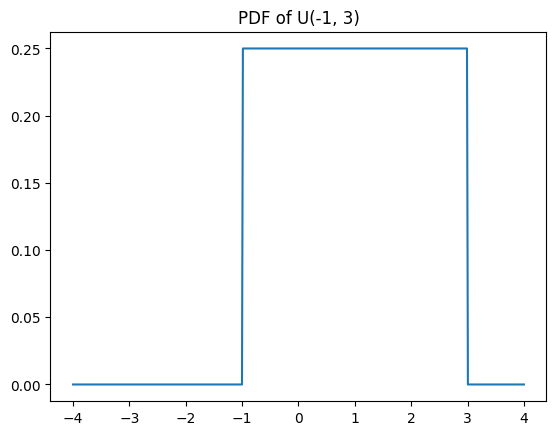

In [94]:
x = np.linspace(-4, 4, 500)
pdf = uniform_dist.pdf(x)

plt.plot(x, pdf)
plt.title("PDF of U(-1, 3)")
plt.show()

In [95]:
prob = uniform_dist.cdf(2) - uniform_dist.cdf(0)
print(prob)

0.5


In [108]:
uniform_dist.cdf(2.9)

np.float64(0.975)

In [97]:
uniform_dist.cdf(2)
uniform_dist.cdf(0)

np.float64(0.25)

In [99]:
mean = uniform_dist.mean()
mean

np.float64(1.0)

In [100]:
variance = uniform_dist.var()
variance

np.float64(1.3333333333333333)

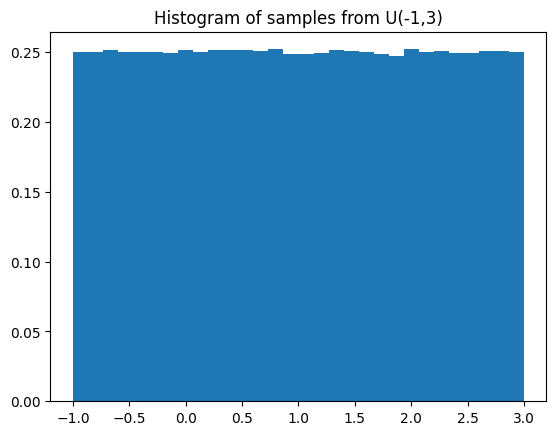

In [104]:
sample = uniform_dist.rvs(size=1000000)
plt.hist(sample, bins=30, density=True)
plt.title("Histogram of samples from U(-1,3)")
plt.show()

In [106]:
print("Theoretical PDF height:", 1/(b-a))

Theoretical PDF height: 0.25


## Import + test data

In [5]:
import numpy as np
import pandas as pd
from scipy import stats

np.random.seed(42)

n = 500
x = np.random.normal(loc=0, scale=1, size=n)
y = 0.5*x + np.random.normal(scale=1.2, size=n)

# дві вибірки для порівнянь
a = np.random.normal(loc=0.0, scale=1.0, size=120)
b = np.random.normal(loc=0.35, scale=1.0, size=110)

# парні (до/після)
before = np.random.normal(loc=10, scale=2, size=60)
after  = before + np.random.normal(loc=0.4, scale=1.0, size=60)

In [7]:
dist = stats.norm(loc=0, scale=1)

samples = dist.rvs(size=5)
pdf0 = dist.pdf(0)
cdf0 = dist.cdf(0)
q975 = dist.ppf(0.975)
print(samples, pdf0, cdf0, q975)

[-2.59104229 -0.54624445  0.39180401 -1.47891157  0.18335992] 0.3989422804014327 0.5 1.959963984540054


In [8]:
binom = stats.binom(n=20, p=0.3)

pmf6= binom.pmf(6)
p_le_6 = binom.cdf(6)
q90 = binom.ppf(0.90)

print(pmf6, p_le_6, q90)

0.1916389827534426 0.6080098122009243 9.0


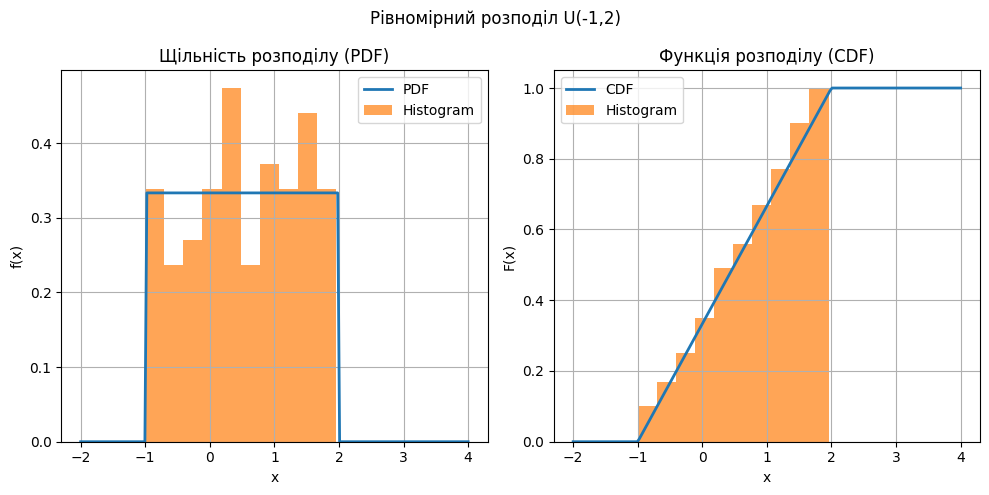

In [4]:
import matplotlib.pyplot as plt
from scipy.stats import uniform
sample = uniform(loc=-1, scale=3).rvs(size=100, random_state=29)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
x = np.linspace(-2, 4, 200)
updf = uniform(loc=-1, scale=3).pdf(x)
ax[0].plot(x, updf, lw=2, label='PDF')
ax[0].hist(sample, density=True, cumulative=False, alpha=0.7, label='Histogram')
ax[0].set_title('Щільність розподілу (PDF)')
ax[0].set_xlabel('x')
ax[0].set_ylabel('f(x)')
ax[0].legend()
ax[0].grid(True)
ucdf = uniform(loc=-1, scale=3).cdf(x)
ax[1].plot(x, ucdf, lw=2, label='CDF')
ax[1].hist(sample, density=True, cumulative=True, alpha=0.7, label='Histogram')
ax[1].set_title('Функція розподілу (СDF)')
ax[1].set_xlabel('x')
ax[1].set_ylabel('F(x)')
ax[1].legend()
ax[1].grid(True)
plt.suptitle('Рівномірний розподіл U(-1,2)', fontsize=12)
plt.tight_layout()
plt.show()


## 0) Імпорти

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid", context="notebook")

np.random.seed(42)

n = 500
x = np.random.normal(0, 1, n)
a = np.random.normal(0.0, 1.0, 120)
b = np.random.normal(0.35, 1.0, 110)

## 1) Розподіли: PDF, CDF, гістограма + теоретична крива

### 1.1 Normal: гістограма + теоретична PDF

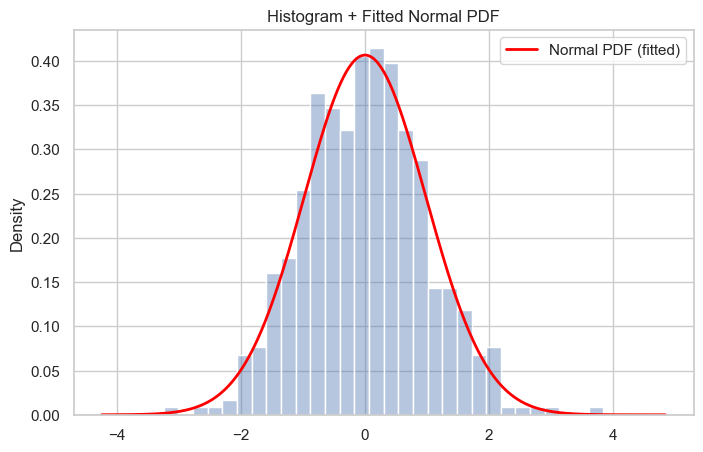

In [22]:
fig, ax = plt.subplots(figsize=(8,5))

# histogram
sns.histplot(x, bins=30, stat="density", alpha=0.4, ax=ax)


# theoretical curve
grid = np.linspace(x.min()-1, x.max()+1, 400)
pdf = stats.norm.pdf(grid, loc=np.mean(x), scale=np.std(x,ddof=1))

ax.plot(grid, pdf, color="red", lw=2, label="Normal PDF (fitted)")
ax.set_title("Histogram + Fitted Normal PDF")
ax.legend()

plt.show()

### 1.2 CDF

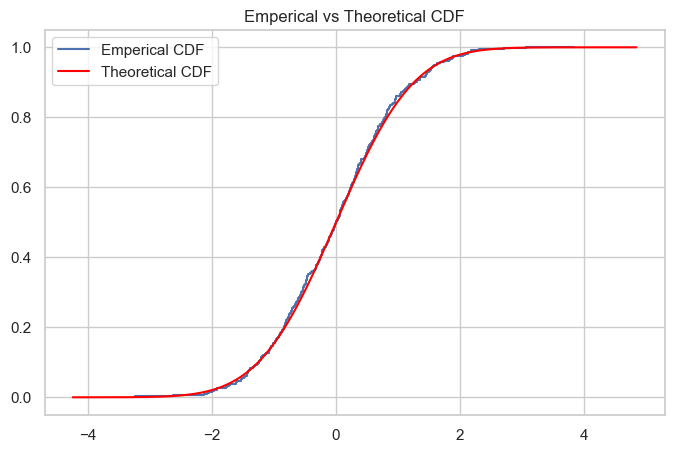

In [16]:
fig, ax = plt.subplots(figsize=(8,5))

sorted_x = np.sort(x)
ecdf = np.arange(1, len(x)+1) / len(x)

ax.step(sorted_x, ecdf, label="Emperical CDF")

grid = np.linspace(x.min()-1, x.max()+1, 400)
ax.plot(grid, stats.norm.cdf(grid, np.mean(x), np.std(x, ddof=1)),
       color="red", label="Theoretical CDF")

ax.set_title("Emperical vs Theoretical CDF")
ax.legend()
plt.show()

## 2) KDE (ядерна оцінка щільності)

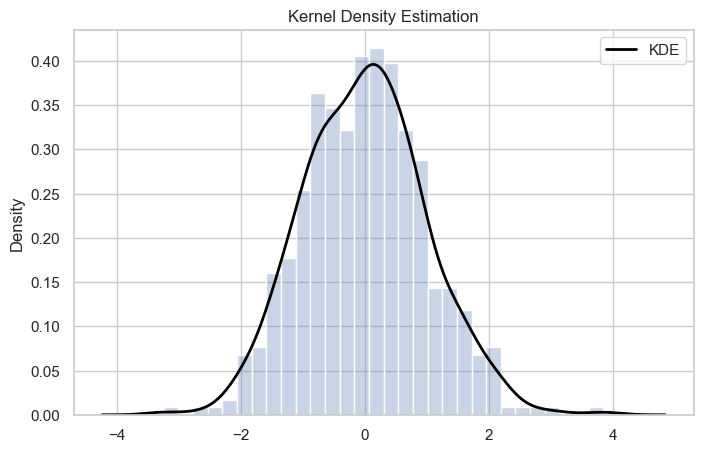

In [23]:
fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(x, bins=30, stat="density", alpha=0.3, ax=ax)

kde = stats.gaussian_kde(x)
grid = np.linspace(x.min()-1, x.max()+1, 400)
ax.plot(grid, kde(grid), color="black", lw=2, label="KDE")

ax.set_title("Kernel Density Estimation")
ax.legend()
plt.show()

## 3) Довірчий інтервал для середнього (візуалізація)

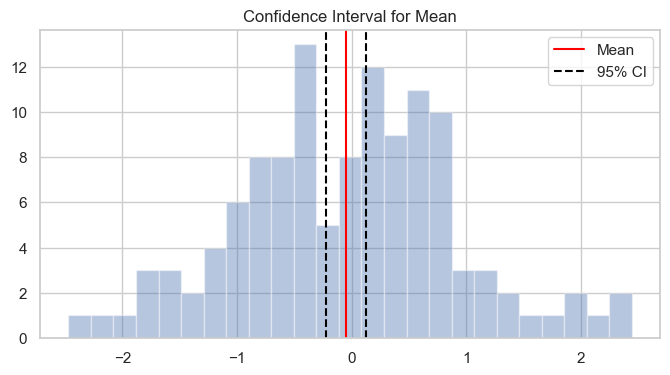

In [24]:
mean = np.mean(a)
se = stats.sem(a)
tcrit = stats.t.ppf(0.975, df=len(a)-1)
ci = (mean - tcrit*se, mean + tcrit*se)

fig, ax = plt.subplots(figsize=(8,4))

ax.hist(a, bins=25, alpha=0.4)
ax.axvline(mean, color="red", label="Mean")
ax.axvline(ci[0], color="black", linestyle="--", label="95% CI")
ax.axvline(ci[1], color="black", linestyle="--")

ax.set_title("Confidence Interval for Mean")
ax.legend()
plt.show()

## 4) Двовибірковий t-test (порівняння розподілів)

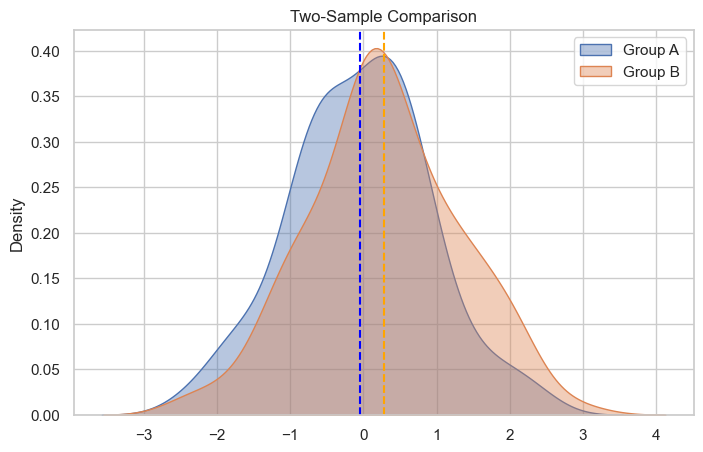

t = -2.4618957573830365 p = 0.014580595585937627


In [25]:
fig, ax = plt.subplots(figsize=(8,5))

sns.kdeplot(a, fill=True, alpha=0.4, label="Group A", ax=ax)
sns.kdeplot(b, fill=True, alpha=0.4, label="Group B", ax=ax)

ax.axvline(np.mean(a), color="blue", linestyle="--")
ax.axvline(np.mean(b), color="orange", linestyle="--")

ax.set_title("Two-Sample Comparison")
ax.legend()
plt.show()

# test
t_stat, p = stats.ttest_ind(a, b, equal_var=False)
print("t =", t_stat, "p =", p)

## 5) ANOVA (boxplot + результат тесту)

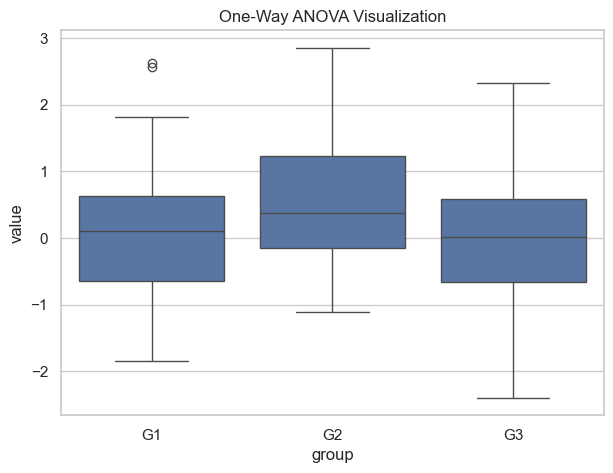

F = 7.220422362819348 p = 0.0009161833856649593


In [26]:
g1 = np.random.normal(0.0, 1.0, 80)
g2 = np.random.normal(0.4, 1.0, 70)
g3 = np.random.normal(-0.2, 1.0, 75)

df_anova = pd.DataFrame({
    "value": np.concatenate([g1, g2, g3]),
    "group": (["G1"]*len(g1) +
              ["G2"]*len(g2) +
              ["G3"]*len(g3))
})

fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(data=df_anova, x="group", y="value", ax=ax)
ax.set_title("One-Way ANOVA Visualization")
plt.show()

f_stat, p = stats.f_oneway(g1, g2, g3)
print("F =", f_stat, "p =", p)

## 6) QQ-plot (перевірка нормальності)

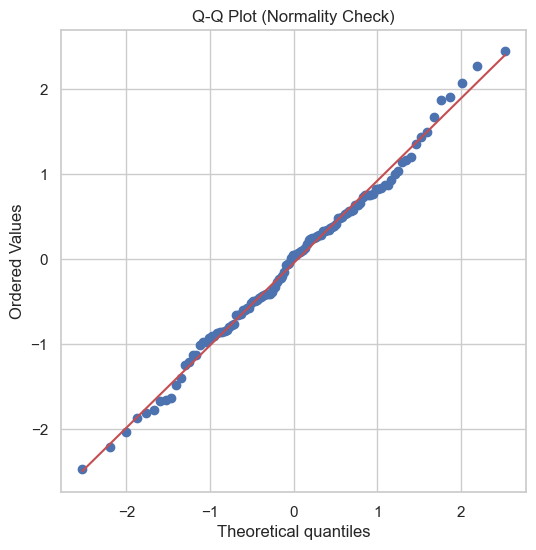

In [29]:
fig = plt.figure(figsize=(6,6))
stats.probplot(a, dist="norm", plot=plt)
plt.title("Q-Q Plot (Normality Check)")
plt.show()

## 7) Монте-Карло (візуалізація симуляції)

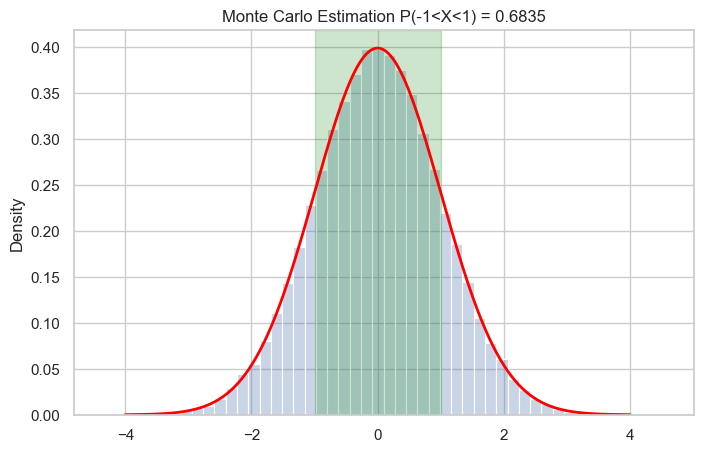

In [35]:
N = 1_00_000
X = stats.norm.rvs(size=N)

p_hat = np.mean((-1 <= X) & (X <= 1))

fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(X, bins=50, stat="density", alpha=0.3, ax=ax)

grid = np.linspace(-4, 4, 400)
ax.plot(grid, stats.norm.pdf(grid), color="red", lw=2)

ax.axvspan(-1, 1, color="green", alpha=0.2)
ax.set_title(f"Monte Carlo Estimation P(-1<X<1) = {p_hat:.4f}")

plt.show()

## 8) Пермутаційний тест (Monte-Carlo p-value) + візуалізація

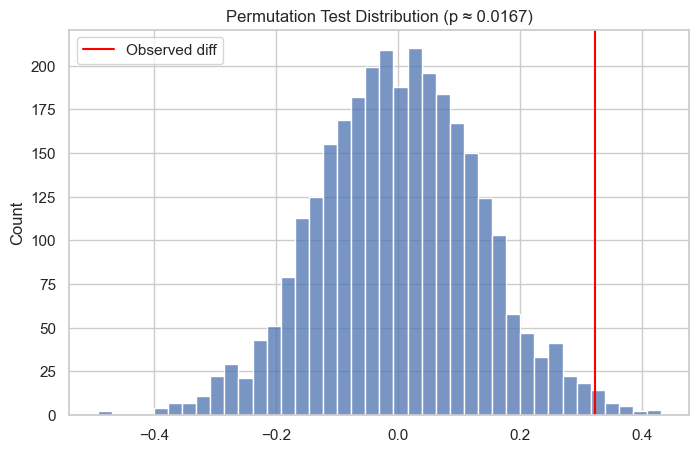

In [36]:
rng = np.random.default_rng(0)

obs = np.mean(b) - np.mean(a)
pool = np.concatenate([a, b])
na = len(a)

B = 3000
perm_stats = np.empty(B)

for i in range(B):
    rng.shuffle(pool)
    perm_stats[i] = np.mean(pool[na:]) - np.mean(pool[:na])

p_mc = np.mean(np.abs(perm_stats) >= np.abs(obs))

fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(perm_stats, bins=40, ax=ax)
ax.axvline(obs, color="red", label="Observed diff")
ax.set_title(f"Permutation Test Distribution (p ≈ {p_mc:.4f})")
ax.legend()

plt.show()